# Moon Classification with N11
Let's repeat the toy classification problem with moon dataset.
We will build a multi-input single-output neural network model with 1 hidden layer.

1. Training
    1. Prepare datasets: training and validation
        1. Load raw data.
        2. Rescale and reshape.
    2. Initialize model (with random parameters: w, b).
    3. Evaluate the model with metrics (e.g. BCE).
    4. Calculate gradients of loss.
    5. Update parameters a small step on the directions descending the gradient of loss.
    6. Repeat 3 to 5 until converge.



## 1. Prepare Datasets
### 1.1. Create Raw Training and Validation Datasets

In [10]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

raw_features_train, raw_labels_train = make_moons(n_samples=1024, noise=0.2, random_state=3321)
raw_features_val, raw_labels_val = make_moons(n_samples=256, noise=0.2)

# First impression on training set
print(f"Samples of raw training features:\n{raw_features_train[:10]}")
print(f"Samples of raw training labels: \n{raw_labels_train[:10]}")
print(f"Shape of training features: {raw_features_train.shape}, Shape of training labels: {raw_labels_train.shape}")
# First impression on validation set
print(f"Samples of raw validation features:\n{raw_features_val[:5]}")
print(f"Samples of raw validation labels: \n{raw_labels_val[:5]}")
print(f"Shape of validation features: {raw_features_val.shape}, Shape of validation labels: {raw_labels_val.shape}")


Samples of raw training features:
[[-0.86691851 -0.32027284]
 [ 1.70922817 -0.66094909]
 [ 0.95477398  0.28453102]
 [ 0.14465106  0.33336045]
 [ 0.58070122  0.65058253]
 [ 1.33531488 -0.2647643 ]
 [ 1.46344736 -0.55310411]
 [-1.20787839  0.52778545]
 [ 0.47737585 -0.2020379 ]
 [ 1.45674566 -0.27188258]]
Samples of raw training labels: 
[0 1 0 1 0 1 1 0 1 1]
Shape of training features: (1024, 2), Shape of training labels: (1024,)
Samples of raw validation features:
[[ 1.21602363  0.36743642]
 [-0.50379062  0.92019987]
 [ 0.99675532  0.56323248]
 [-0.39802744  0.82955419]
 [-0.18207323  1.01420429]]
Samples of raw validation labels: 
[0 0 0 0 0]
Shape of validation features: (256, 2), Shape of validation labels: (256,)


### 1.3. Pre-Process Raw Data
1. Standardize a feature, $\mathbf{x}$, using mean, $\mu$, and standard deviation, $\sigma$, of the feature $(\mathbf{x} - \mu) / \sigma$.
2. Reshape label to column vectors.

Shape of reshaped training labels: (1024, 1)
Shape of reshaped validation labels: (256, 1)


Text(0.5, 1.0, 'Validation Set')

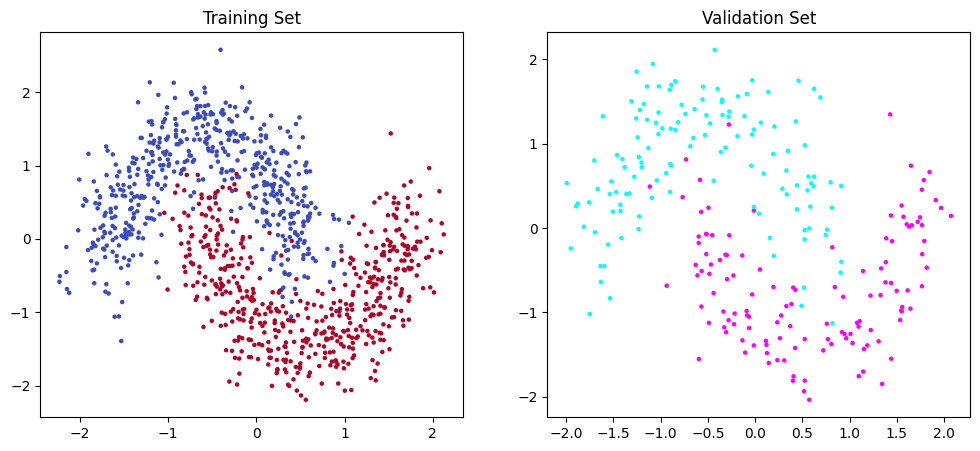

In [11]:
# Rescale by mean and standard deviation
features_train = (raw_features_train - raw_features_train.mean(axis=0)) / raw_features_train.std(axis=0)
features_val = (raw_features_val - raw_features_train.mean(axis=0)) / raw_features_train.std(axis=0)

# Reshape labels
labels_train = raw_labels_train.reshape(-1, 1)
print(f"Shape of reshaped training labels: {labels_train.shape}")
labels_val = raw_labels_val.reshape(-1, 1)
print(f"Shape of reshaped validation labels: {labels_val.shape}")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(
    features_train[:, 0], 
    features_train[:, 1], 
    s=5*np.ones(labels_train.size), 
    c=labels_train, 
    cmap='coolwarm'
)
plt.title("Training Set")

plt.subplot(1, 2, 2)
plt.scatter(
    features_val[:, 0], 
    features_val[:, 1], 
    s=5*np.ones(labels_val.size), 
    c=labels_val, 
    cmap='cool'
)
plt.title("Validation Set")

## 2. N11 Model
 
$$
\begin{align*} 
    \hat{\mathbf{y}} &= \sigma(\mathbf{X}^{[1]} \cdot \mathbf{w}^{[2]T} + \mathbf{b}^{[2]}) \\
    &= \sigma(\sigma(\mathbf{X}^{[0]} \cdot \mathbf{W}^{[1]T} + \mathbf{b}^{[1]}) \cdot \mathbf{w}^{[2]T} + \mathbf{b}^{[2]})
\end{align*}
$$

In [12]:
def linear(in_features, weight, bias):
    out_features = in_features @ weight.T + bias
    return out_features

def sigmoid(in_features):
    return 1 / (1 + np.exp(-in_features))

def forward(in_features, params):
    hidden_features = sigmoid(linear(in_features, params['W1'], params['b1']))
    predictions = sigmoid(linear(hidden_features, params['W2'], params['b2']))
    return predictions, hidden_features

# Sanity check
params_dummy = {
    'W1': np.random.normal(size=(4, features_train.shape[1])),  # (4, 2)
    'b1': np.random.normal(size=(1, 4)),
    'W2': np.random.normal(size=(1, 4)),
    'b2': np.random.normal()
}

preds_dummy, X1_dummy = forward(features_train, params_dummy)
print(f"Hidden features (X1) shape: {X1_dummy.shape}")
print(f"Samples of hidden features (X1):\n{X1_dummy[:3]}")
print(f"Shape of dummy predictions: {preds_dummy.shape}")
print(f"Dummy predictions:\n{preds_dummy}")
print(f"Dummy predicted class labels:\n{(preds_dummy >= 0.5).astype(int)}")

Hidden features (X1) shape: (1024, 4)
Samples of hidden features (X1):
[[0.48360961 0.08637205 0.83126951 0.9221561 ]
 [0.24705234 0.83045277 0.72749753 0.9765351 ]
 [0.54129051 0.84618346 0.66181547 0.75390703]]
Shape of dummy predictions: (1024, 1)
Dummy predictions:
[[0.55253841]
 [0.43495372]
 [0.53076725]
 ...
 [0.56514174]
 [0.63393523]
 [0.52629489]]
Dummy predicted class labels:
[[1]
 [0]
 [1]
 ...
 [1]
 [1]
 [1]]


### 2.1. Visualize Descision Boundaries

Text(0.5, 1.0, 'Validation Set Decision Boundary (Dummy Params)')

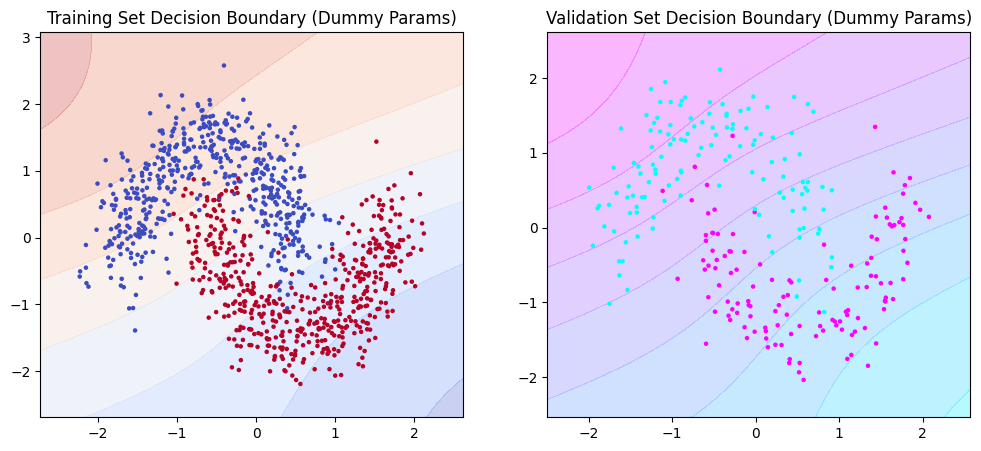

In [15]:
def plot_decision_boundary(features, labels, params, color_map='coolwarm'):
    # Set min and max values and give it some padding
    x_min, x_max = features[:, 0].min() - 0.5, features[:, 0].max() + 0.5
    y_min, y_max = features[:, 1].min() - 0.5, features[:, 1].max() + 0.5
    # Generate a grid of points with distance 0.01 between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    # Predict the function value for the whole grid
    zz = forward(np.c_[xx.ravel(), yy.ravel()], params)[0]
    zz = zz.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, zz, cmap=color_map, alpha=0.3)
    plt.scatter(
        features[:, 0], 
        features[:, 1], 
        c=labels, 
        s=5*np.ones(labels.size), 
        cmap=color_map, 
    )

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(features_train, labels_train, params_dummy)
plt.title("Training Set Decision Boundary (Dummy Params)")
plt.subplot(1, 2, 2)
plot_decision_boundary(features_val, labels_val, params_dummy, 'cool')
plt.title("Validation Set Decision Boundary (Dummy Params)")

## 3. Model Performance Metrics
### 3.1. Binary Cross Entropy Loss
$\mathcal{L}(\hat{\mathbf{y}}, \mathbf{y}) = \frac{1}{M} \sum_{i=1}^{M} -{}^{(i)}y \ln {}^{(i)}\hat{y} - (1 - {}^{(i)}y) \ln (1 - {}^{(i)}\hat{y}) = \overline{-\mathbf{y} \ln \hat{\mathbf{y}} - (1 - \mathbf{y}) \ln (1 - \hat{\mathbf{y}})}$



In [16]:
def bce_fn(preds, labels):
    loss = -labels * np.log(preds) - (1 - labels) * np.log(1 - preds)
    return loss.mean()

print(f"BCE Loss: {bce_fn(preds_dummy, labels_train)}")


BCE Loss: 0.8122777914093822


### 3.2. Accuracy
$$Accuracy = \frac{TP + TN}{TP + FP + FN + TN}$$

> For classification problems, other metrics such as sensitivity and precision are also important.

In [18]:
def accuracy(preds, labels):
    preds_binary = (preds >= 0.5).astype(int)
    return (preds_binary == labels).mean()

print(f"Accuracy: {accuracy(preds_dummy, labels_train) * 100}%")

Accuracy: 19.82421875%


## 4. Back-Propagate Gradients of Loss
$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}^{[2]}} = \frac{1}{M} (\mathbf{\hat{y}} - \mathbf{y})^T \cdot \mathbf{X}^{[1]}$$

$$\frac{\partial \mathcal{L}}{\partial b^{[2]}} = \overline{(\mathbf{\hat{y}} - \mathbf{y})}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{X}^{[1]}} = (\mathbf{\hat{y}} - \mathbf{y})^T \cdot \mathbf{w}^{[2]}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[1]}} = \frac{1}{M} [(\mathbf{\hat{y}} - \mathbf{y}) \cdot \mathbf{w}^{[2]} * \mathbf{X}^{[1]} * (1 - \mathbf{X}^{[1]})]^T \cdot \mathbf{X}^{[0]}$$

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[1]}} = \overline{
    (\mathbf{\hat{y}} - \mathbf{y}) \cdot \mathbf{w}^{[2]} * \mathbf{X}^{[1]} * (1 - \mathbf{X}^{[1]})
} \text{, on 1st dimension}
$$


In [24]:
def backward(in_features, hidden_features, predictions, labels, params):
    M = labels.shape[0]
    dL_dW2 = (predictions - labels).T @ hidden_features / M
    dL_db2 = (predictions - labels).mean()
    dL_dX1 = (predictions - labels) @ params['W2']
    dL_dW1 = (dL_dX1 * hidden_features * (1 - hidden_features)).T @ in_features / M
    dL_db1 = (dL_dX1 * hidden_features * (1 - hidden_features)).mean(axis=0, keepdims=True)
    grads = {
        'dW2': dL_dW2,
        'db2': dL_db2,
        'dW1': dL_dW1,
        'db1': dL_db1
    }   

    return grads

# Sanity check
grads_dummy = backward(features_train, X1_dummy, preds_dummy, labels_train, params_dummy)
for k, v in grads_dummy.items():
    print(f"{k}: \n{v}, shape: {v.shape}") 


dW2: 
[[ 0.10329347  0.00717152  0.0272543  -0.06769936]], shape: (1, 4)
db2: 
0.04965376126426273, shape: ()
dW1: 
[[-0.08204734  0.09502222]
 [ 0.00879914 -0.01475111]
 [-0.025823    0.03256077]
 [ 0.01663455 -0.01808128]], shape: (4, 2)
db1: 
[[ 0.0046476  -0.00154049  0.00489906 -0.01232777]], shape: (1, 4)


## 5. Iterative Parameter Optimization

Iter 0: Train Loss 2.1956616189422817, Train Accuracy 49.21875%
Iter 0: Validation Loss 2.1864031739833987, Validation Accuracy 49.609375%
Iter 50: Train Loss 0.2955412410492435, Train Accuracy 87.3046875%
Iter 50: Validation Loss 0.2915534763847224, Validation Accuracy 87.890625%
Iter 100: Train Loss 0.28757741867799885, Train Accuracy 87.6953125%
Iter 100: Validation Loss 0.28412306791200825, Validation Accuracy 87.890625%
Iter 150: Train Loss 0.28087644361515846, Train Accuracy 87.6953125%
Iter 150: Validation Loss 0.2776865715272024, Validation Accuracy 88.28125%
Iter 200: Train Loss 0.2744640954849962, Train Accuracy 88.0859375%
Iter 200: Validation Loss 0.27146962608120995, Validation Accuracy 89.453125%
Iter 250: Train Loss 0.2682213622532653, Train Accuracy 88.4765625%
Iter 250: Validation Loss 0.2654106322458744, Validation Accuracy 89.453125%
Iter 300: Train Loss 0.2620891068845316, Train Accuracy 88.8671875%
Iter 300: Validation Loss 0.2594678252132306, Validation Accuracy 8

(0.0, 1.0)

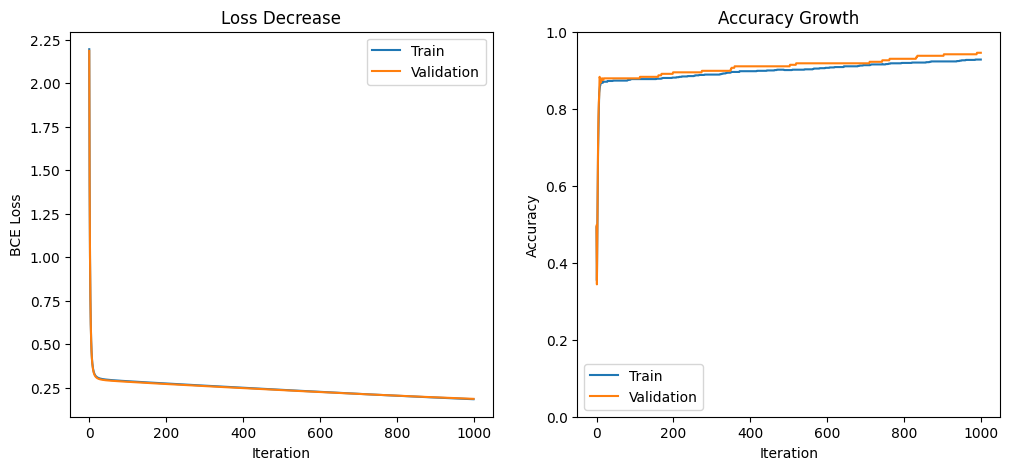

In [27]:
# Set hyperparameters
num_iters = 1000
learning_rate = 0.2

# Initialize parameters
params = {
    'W1': np.random.normal(size=(64, features_train.shape[1])),  # (4, 2)
    'b1': np.random.normal(size=(1, 64)),
    'W2': np.random.normal(size=(1, 64)),
    'b2': np.random.normal()
}

# Reserve metrics storage
losses_train, lossese_val = [], []
accuracies_train, accuracies_val = [], []

# Optimization iterations
for i in range(num_iters):
    # Forward pass
    preds_train, hid_feats_train = forward(features_train, params)
    preds_val, hid_feats_val = forward(features_val, params)
    # Compute loss and accuracy
    loss_train = bce_fn(preds_train, labels_train)
    loss_val = bce_fn(preds_val, labels_val)
    acc_train = accuracy(preds_train, labels_train)
    acc_val = accuracy(preds_val, labels_val)
    losses_train.append(loss_train)
    lossese_val.append(loss_val)
    accuracies_train.append(acc_train)
    accuracies_val.append(acc_val)
    # Log progress (every 50 iterations)   
    if i % 50 == 0 or i == num_iters - 1:
        print(f"Iter {i}: Train Loss {loss_train}, Train Accuracy {acc_train * 100}%")
        print(f"Iter {i}: Validation Loss {loss_val}, Validation Accuracy {acc_val * 100}%")
    # Back-propagation
    grads = backward(features_train, hid_feats_train, preds_train, labels_train, params)
    # Gradient descent parameter update
    params['W1'] = params['W1'] - learning_rate * grads['dW1']
    params['b1'] = params['b1'] - learning_rate * grads['db1']
    params['W2'] = params['W2'] - learning_rate * grads['dW2']
    params['b2'] = params['b2'] - learning_rate * grads['db2']

# Plot learning curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(num_iters), losses_train, range(num_iters), lossese_val)
plt.legend(['Train', 'Validation'])
plt.title("Loss Decrease")
plt.xlabel("Iteration")
plt.ylabel("BCE Loss")
plt.subplot(1, 2, 2)
plt.plot(range(num_iters), accuracies_train, range(num_iters), accuracies_val)
plt.legend(['Train', 'Validation'])
plt.title("Accuracy Growth")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

### 5.1. Visualize Trained Descision Boundaries


Text(0.5, 1.0, 'Validation Set Decision Boundary')

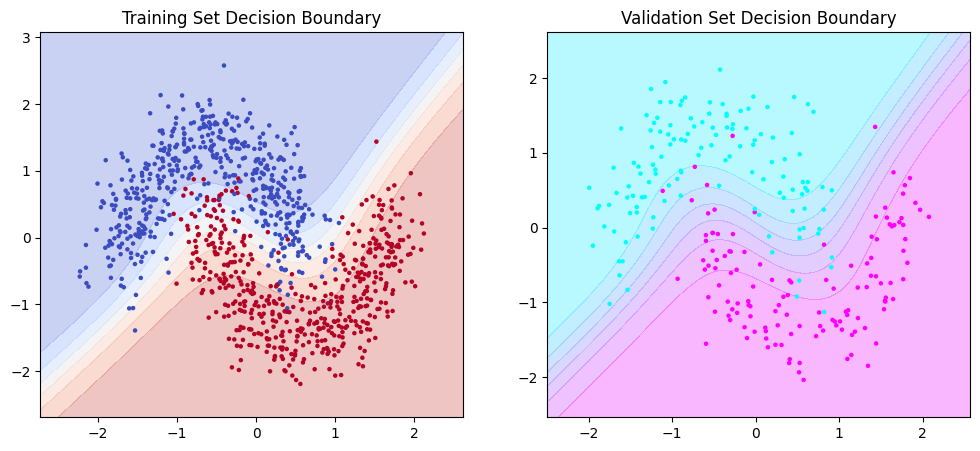

In [28]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(features_train, labels_train, params)
plt.title("Training Set Decision Boundary")
plt.subplot(1, 2, 2)
plot_decision_boundary(features_val, labels_val, params, 'cool')
plt.title("Validation Set Decision Boundary")